In [1]:
import pandas as pd
df = pd.read_csv('raw.csv')

In [2]:
df.shape

(3973, 31)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3973 entries, 0 to 3972
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    3973 non-null   int64  
 1   V1      3973 non-null   float64
 2   V2      3973 non-null   float64
 3   V3      3973 non-null   float64
 4   V4      3973 non-null   float64
 5   V5      3973 non-null   float64
 6   V6      3973 non-null   float64
 7   V7      3973 non-null   float64
 8   V8      3973 non-null   float64
 9   V9      3973 non-null   float64
 10  V10     3973 non-null   float64
 11  V11     3973 non-null   float64
 12  V12     3973 non-null   float64
 13  V13     3973 non-null   float64
 14  V14     3973 non-null   float64
 15  V15     3973 non-null   float64
 16  V16     3973 non-null   float64
 17  V17     3973 non-null   float64
 18  V18     3973 non-null   float64
 19  V19     3973 non-null   float64
 20  V20     3973 non-null   float64
 21  V21     3973 non-null   float64
 22  

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,3973.000000,3973.000000,3973.000000,3973.000000,3973.000000,3973.000000,3973.000000,3973.000000,3973.000000,3973.000000,...,3973.000000,3973.000000,3972.000000,3972.000000,3972.000000,3972.000000,3972.000000,3972.000000,3972.000000,3972.000000
mean,1638.724138,-0.333723,0.308691,0.837062,0.013144,-0.029177,0.052836,0.146895,-0.071352,0.055778,...,0.010465,-0.082885,-0.058484,0.029106,0.095278,-0.012623,0.044638,0.002639,65.000101,0.000504
std,1016.577498,1.351976,1.180436,0.981057,1.418751,1.207632,1.286610,1.090769,1.294647,0.919087,...,0.855829,0.635482,0.391158,0.603965,0.405989,0.503818,0.352752,0.254136,213.688183,0.022437
min,0.000000,-12.168192,-15.732974,-12.389545,-4.657545,-32.092129,-7.465603,-11.164794,-23.632502,-3.336805,...,-11.273890,-5.707801,-7.996811,-2.162523,-2.322906,-1.338556,-5.336289,-2.909294,0.000000,0.000000
25%,750.000000,-1.030747,-0.155734,0.287224,-0.908469,-0.573740,-0.735876,-0.278697,-0.205430,-0.473894,...,-0.211812,-0.512434,-0.210615,-0.338940,-0.141891,-0.339998,-0.041461,-0.020983,2.265000,0.000000
50%,1526.000000,-0.451819,0.409641,0.884503,0.099497,-0.089809,-0.209577,0.162196,0.028639,0.032286,...,-0.053234,-0.064435,-0.069939,0.100635,0.108219,-0.025647,0.033751,0.021264,12.990000,0.000000
75%,2526.000000,1.070572,0.921588,1.433851,0.982710,0.396675,0.449217,0.635055,0.298866,0.622704,...,0.102520,0.345346,0.062502,0.432692,0.361309,0.288406,0.205736,0.087058,54.990000,0.000000
max,3624.000000,1.685314,6.118940,4.017561,6.013346,10.658654,21.393069,34.303177,3.877662,6.450992,...,15.631453,4.393846,4.095021,1.215279,1.727063,3.463246,3.852046,4.157934,7712.430000,1.000000


In [5]:
df['Class'].value_counts()

,count
Class,
0.0,3970
1.0,2


In [6]:
df['Class'].value_counts(normalize=True)

,proportion
Class,
0.0,0.999496
1.0,0.000504


In [7]:
# Extreme class imbalance, Accuracy is useless
# Focusing on recall + precision

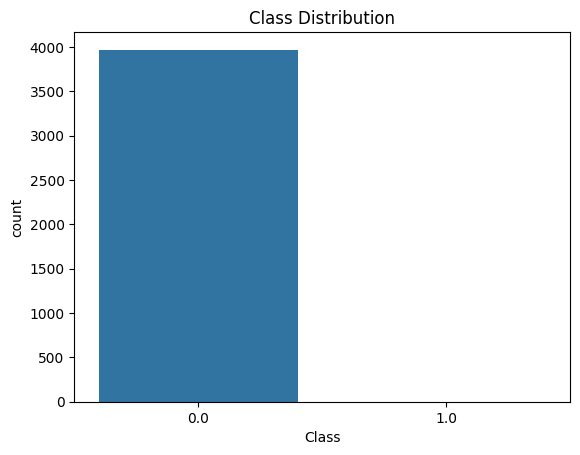

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()


In [9]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [10]:
df[df.isnull().any(axis=1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
3972,3624,-0.663445,1.162921,1.50805,0.549405,0.231377,-0.106041,0.817977,-0.387026,1.488054,...,-0.420337,-0.361357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df = df.dropna()

In [12]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


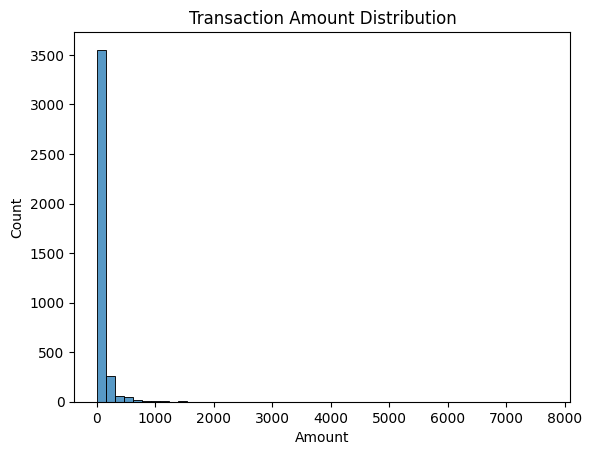

In [13]:
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

In [14]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print("Fraud mean:", fraud['Amount'].mean())
print("Normal mean:", normal['Amount'].mean())

Fraud mean: 264.5
Normal mean: 64.89959697732998


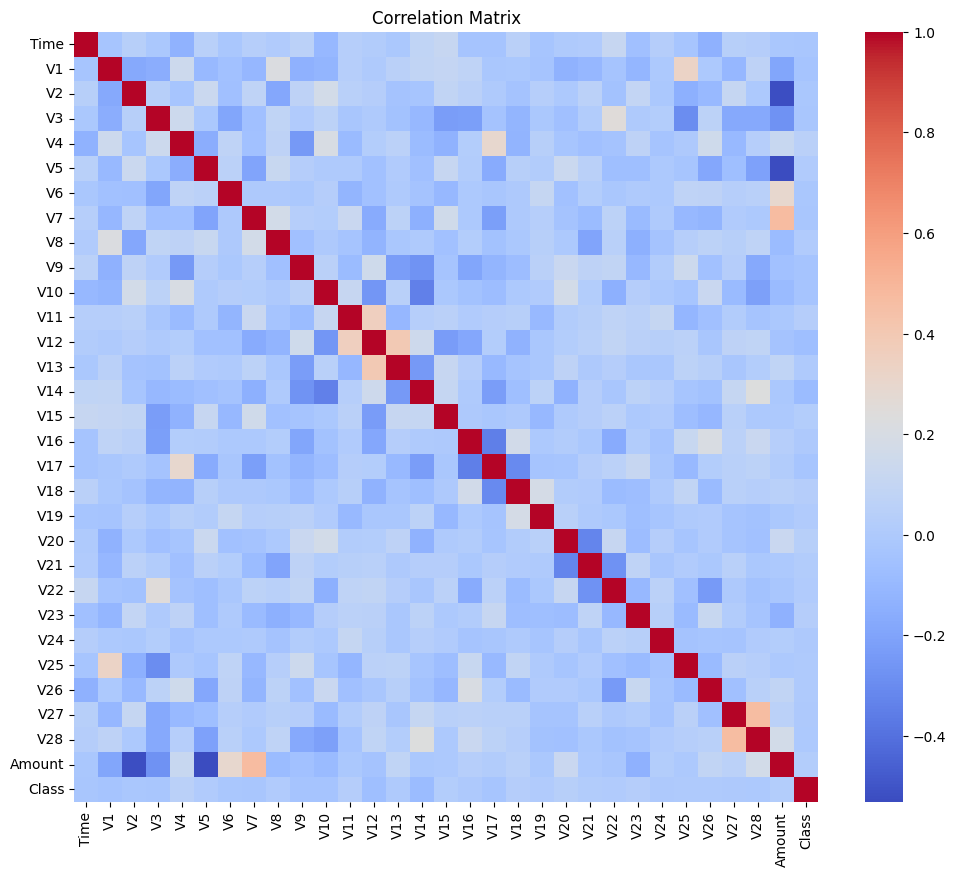

In [16]:
corr = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [17]:
corr['Class'].sort_values(ascending=False)

,Class
Class,1.000000
V4,0.049523
V20,0.040693
V23,0.029490
V18,0.029418
V11,0.028237
V15,0.023122
Amount,0.020957
V21,0.015182
V8,0.012711


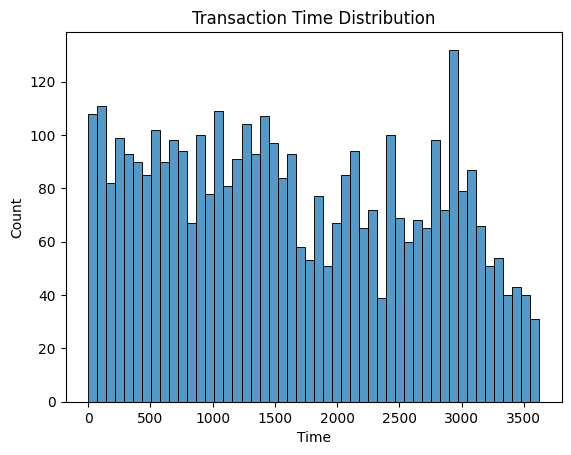

In [18]:
sns.histplot(df['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

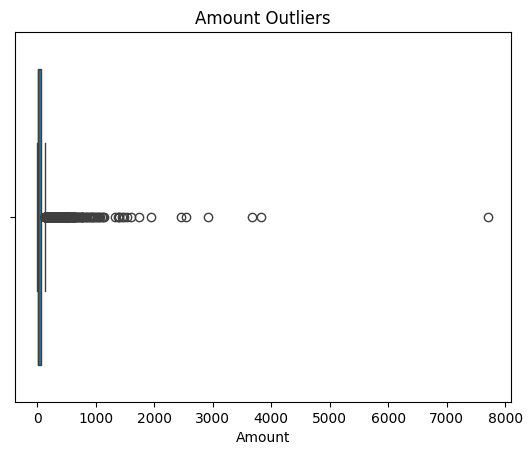

In [19]:
sns.boxplot(x=df['Amount'])
plt.title("Amount Outliers")
plt.show()

#Key Findings
1. Dataset is extremely imbalanced (~0.17%)
2. No missing values (1 corrupted record, was removed)
3. Features are PCA-Transformed
4. Amount is skewed, Requires scaling
5. Some features strongly correlate with fraud
6. Time can be used for streaming simulation

#Implication for modeling
1. Use class imbalance handeling
2. Use precision/recall instead of accuracy
3. Apply scaling
4. Consider threshold tuning

/tmp/ipykernel_9718/2176943401.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(fraud['Amount'], label='Fraud', shade=True)
/tmp/ipykernel_9718/2176943401.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(normal['Amount'], label='Normal', shade=True)


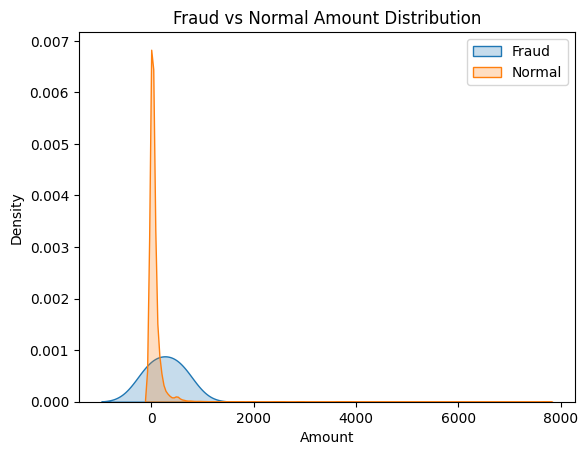

In [20]:
sns.kdeplot(fraud['Amount'], label='Fraud', shade=True)
sns.kdeplot(normal['Amount'], label='Normal', shade=True)
plt.title("Fraud vs Normal Amount Distribution")
plt.legend()
plt.show()